# 03 - Extracción de características
**Proyecto:** Detección Asistida de Leucemia Linfoblástica Aguda (LLA)  
**Dataset:** Segmented (una célula por imagen)  

## Objetivo
Cálculo de descriptores geométricos precisos sobre los núcleos aislados, tales como área, perímetro, circularidad y análisis de irregularidades en los bordes. Esto es crucial, ya que los blastos leucémicos presentan núcleos notablemente más grandes y deformes (lobulados) que los linfocitos sanos.
- **Métricas Geométricas:** Área, perímetro y circularidad.
- **Métricas Relacionales:** Relación Núcleo-Citoplasma (N/C), factor crítico ya que los blastos típicamente muestran núcleos hipertrofiados que ocupan casi toda la célula.
- **Métricas de Textura:** Uso de Matrices de Co-ocurrencia de Niveles de Gris (GLCM) para describir matemáticamente la laxitud de la cromatina dentro del núcleo.

## Estructura del notebook
- **Parte A:** Metricas Geometricas
- **Parte B:** Métricas Relacionales
- **Parte C:** Métricas de textura

## 0. Importación de librerías y rutas

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import ndimage
import pandas as pd


In [3]:
import cv2
import numpy as np
import pandas as pd  # <-- Esto quita la línea roja de error de la captura
import matplotlib.pyplot as plt

In [4]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path

In [5]:

RAW_PATH = Path('../data/raw/Original')
CLASSES  = ['Benign', 'Early', 'Pre', 'Pro']
COLORES  = {'Benign': '#2ecc71', 'Early': '#e74c3c', 'Pre': '#e67e22', 'Pro': '#9b59b6'}

print('Librerías cargadas OK')

Librerías cargadas OK


## 0.2 Función de preprocesamiento (del notebook 01)
Reutilizamos el pipeline validado: `BGR → HSV → canal S → Mediana`

In [6]:
def preprocesamiento(img_path, filtro='mediana', ksize=5):
    """
    Pipeline completo de preprocesamiento:
      1. Carga imagen
      2. Convierte a HSV y extrae canal S
      3. Aplica filtro de ruido mediana
    Retorna: imagen original RGB, canal S sin procesar, canal S preprocesado
    """
    img_bgr = cv2.imread(str(img_path))
    
    # Seguro por si alguna ruta se rompe en otra compu
    if img_bgr is None:
        raise FileNotFoundError(f"No se encontró la imagen en: {img_path}")
    

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    canal_s = img_hsv[:,:,1] # Canal S (Saturación - Índice 1)

    if filtro == 'mediana':
        canal_filtrado = cv2.medianBlur(canal_s, ksize)
    elif filtro == 'gaussiano':
        canal_filtrado = cv2.GaussianBlur(canal_s, (ksize, ksize), 0)
    else:
        canal_filtrado = canal_s
        print(f"Filtro '{filtro}' no reconocido. Se devuelve el canal S limpio.")
    
    return img_rgb, canal_s, canal_filtrado



## 0.2 Función de preprocesamiento (del notebook 02)
Reutilizamos el pipeline validado: segmentar_nucleo_otsu 

`Segmenta el núcleo usando umbralización de Otsu con un piso de seguridad.Evita que el umbral baje demasiado en imágenes con ruido de glóbulos rojos`


Reutilizamos el pipeline valido: refinar_mascara_nucleo

 `Aplica operaciones morfológicas para limpiar la máscara del núcleo:1. Apertura: elimina pequeños artefactos y puentes finos.2. Cierre: rellena huecos internos en el núcleo.3. Relleno de agujeros con SciPy: consolida la máscara final.`

In [7]:
def segmentar_nucleo_otsu(canal_proc, umbral_minimo=70):
    """
    Segmenta el núcleo usando umbralización de Otsu con un piso de seguridad.
    Evita que el umbral baje demasiado en imágenes con ruido de glóbulos rojos.
    """
    # 1. Calculamos Otsu estándar
    umbral_otsu, mascara_otsu = cv2.threshold(
        canal_proc, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    
    # 2. Control de seguridad: Si Otsu calculó un umbral muy bajo, forzamos el mínimo
    if umbral_otsu < umbral_minimo:
        # Re-calculamos usando el umbral fijo de seguridad
        _, mascara = cv2.threshold(canal_proc, umbral_minimo, 255, cv2.THRESH_BINARY)
        umbral_final = umbral_minimo
    else:
        mascara = mascara_otsu
        umbral_final = umbral_otsu
        
    return mascara, umbral_final


In [8]:
def refinar_mascara_nucleo(mascara, kernel_size=5):
    """
    Aplica operaciones morfológicas para limpiar la máscara del núcleo:
    1. Apertura: elimina pequeños artefactos y puentes finos.
    2. Cierre: rellena huecos internos en el núcleo.
    3. Relleno de agujeros con SciPy: consolida la máscara final.
    """
    # Usamos un elemento estructurante elíptico (ideal para formas redondeadas de núcleos)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    
    # 1. Apertura (Erosión + Dilatación) - Limpia ruidos externos
    apertura = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    
    # 2. Cierre (Dilatación + Erosión) - Conecta componentes del mismo núcleo
    cierre = cv2.morphologyEx(apertura, cv2.MORPH_CLOSE, kernel)
    
    # 3. Relleno de agujeros internos (SciPy ndimage)
    relleno = ndimage.binary_fill_holes(cierre).astype(np.uint8) * 255
    
    # Retornamos los pasos intermedios para tu gráfico de visualización, 
    # siendo 'relleno' el resultado final optimizado.
    return apertura, cierre, relleno


---
# PARTE A — Metricas geometricas

En este caso se uso otsu para segmentar

--------------------------------------------------
📊 DIAGNÓSTICO CON UMBRAL CORREGIDO:
-> Objetos totales detectados: 7
-> Células válidas finales (>40px): 7
--------------------------------------------------
Muestras de características:
[{'id_celula': 0, 'area': 153.5, 'perimetro': 49.899494647979736, 'circularidad': 0.7746864308752631, 'relacion_aspecto': 1.2307692307692308}, {'id_celula': 1, 'area': 903.0, 'perimetro': 131.53910410404205, 'circularidad': 0.6558248296537704, 'relacion_aspecto': 0.8809523809523809}, {'id_celula': 2, 'area': 362.5, 'perimetro': 74.5269113779068, 'circularidad': 0.820146864139236, 'relacion_aspecto': 0.6428571428571429}, {'id_celula': 3, 'area': 902.0, 'perimetro': 148.71067655086517, 'circularidad': 0.5125451197656782, 'relacion_aspecto': 0.9111111111111111}, {'id_celula': 4, 'area': 392.0, 'perimetro': 90.76955187320709, 'circularidad': 0.5978820959725079, 'relacion_aspecto': 0.4722222222222222}, {'id_celula': 5, 'area': 342.5, 'perimetro': 71.3553384

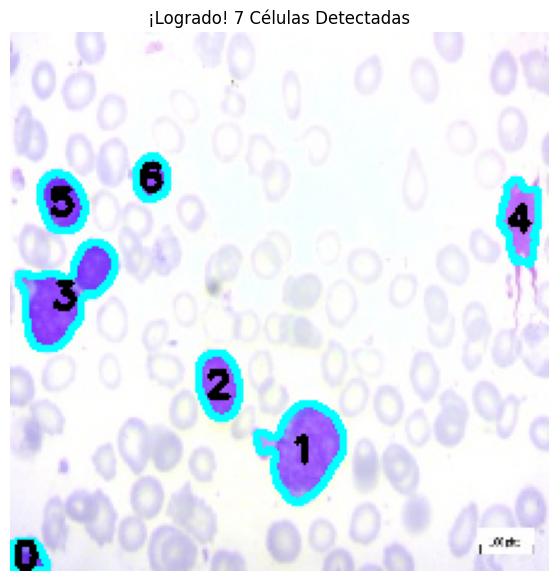

In [9]:
cls= 'Benign'
img_path = list((RAW_PATH /cls).glob('*.jpg'))[0]
# 1. Pasos fijos que ya andan bien
img_rgb, canal_s, canal_proc = preprocesamiento(img_path, filtro='mediana', ksize=5)
mascara_raw, umbral = segmentar_nucleo_otsu(canal_proc, umbral_minimo=70)

# 2. Morfología local en uint8
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)) # Reducimos un toque el kernel
mascara_base = mascara_raw.astype(np.uint8)
apertura = cv2.morphologyEx(mascara_base, cv2.MORPH_OPEN, kernel)
mascara_lista = cv2.morphologyEx(apertura, cv2.MORPH_CLOSE, kernel)

# 3. Extracción de contornos
contornos, _ = cv2.findContours(mascara_lista, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

datos_nucleos = []
img_verificacion = img_rgb.copy()

# !!! BAJAMOS EL UMBRAL DE ÁREA A 40 PORQUE LAS IMÁGENES SON DE 224x224 !!!
UMBRAL_ADAPTADO = 40 

for i, cnt in enumerate(contornos):
    area = cv2.contourArea(cnt)
    
    # Filtro adaptado a resolución baja
    if area >= UMBRAL_ADAPTADO:
        perimetro = cv2.arcLength(cnt, True)
        circularidad = (4 * np.pi * area) / (perimetro ** 2) if perimetro > 0 else 0
        x, y, w, h = cv2.boundingRect(cnt)
        relacion_aspecto = float(w) / h if h > 0 else 0
        
        datos_nucleos.append({
            'id_celula': len(datos_nucleos),
            'area': area,
            'perimetro': perimetro,
            'circularidad': circularidad,
            'relacion_aspecto': relacion_aspecto
        })
        
        # Dibujamos en cian
        cv2.drawContours(img_verificacion, [cnt], -1, (0, 255, 255), 2)
        
        # Ponemos el numerito centrado
        M = cv2.moments(cnt)
        if M["m00"] > 0:
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])
            cv2.putText(img_verificacion, str(len(datos_nucleos)-1), (cX - 5, cY + 5), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2) # Texto negro para que contraste

print("--------------------------------------------------")
print(f"📊 DIAGNÓSTICO CON UMBRAL CORREGIDO:")
print(f"-> Objetos totales detectados: {len(contornos)}")
print(f"-> Células válidas finales (>40px): {len(datos_nucleos)}")
print("--------------------------------------------------")

if len(datos_nucleos) > 0:
    print("Muestras de características:")
    print(datos_nucleos)

plt.figure(figsize=(7, 7))
plt.imshow(img_verificacion)
plt.title(f"¡Logrado! {len(datos_nucleos)} Células Detectadas")
plt.axis('off')
plt.show()

Probando función para extraer caracteristicas métricas de una sola imagen y sus multiples celulas

--------------------------------------------------
🎉 ¡Conteo verificado! Células procesadas: 3
--------------------------------------------------



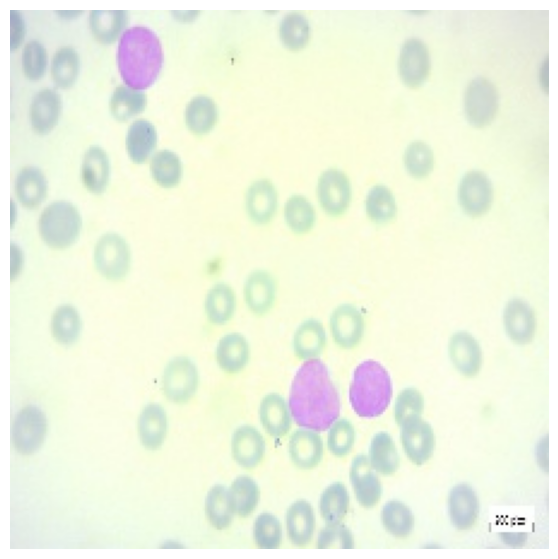

,id_celula,area_nucleo,perimetro_nucleo,circularidad,compacidad,excentricidad,relacion_aspecto
0,0,139.0,51.455843,0.659713,19.048229,0.637253,1.214286
1,1,216.5,56.870057,0.841202,14.938584,0.655060,0.800000
2,2,265.5,64.870057,0.792841,15.849809,0.747283,0.666667


In [10]:

# 1. Función con el set completo de métricas geométricas de la Parte A
def extraer_metricas_geometricas(mascara_nucleo, area_minima=40):
    mascara_proc = np.array(mascara_nucleo, dtype=np.uint8)
    if mascara_proc.max() == 1:
        mascara_proc = mascara_proc * 255
        
    contornos, _ = cv2.findContours(mascara_proc, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    lista_celulas = []
    
    for i, cnt in enumerate(contornos):
        area_n = cv2.contourArea(cnt)
        if area_n < area_minima:
            continue
            
        perimetro_n = cv2.arcLength(cnt, True)
        
        # Métricas geométricas tradicionales
        circularidad = (4 * np.pi * area_n) / (perimetro_n ** 2) if perimetro_n > 0 else 0
        
        # --- APORTE AMPLIADO ---
        # Compacidad
        compacidad = (perimetro_n ** 2) / area_n if area_n > 0 else 0
        
        # Excentricidad (Ajustando una elipse al contorno)
        excentricidad = 0.0
        if len(cnt) >= 5:  # Condición requerida por OpenCV
            _, (eje_menor, eje_mayor), _ = cv2.fitEllipse(cnt)
            if eje_mayor > 0:
                # Fórmula matemática de la excentricidad elíptica
                excentricidad = np.sqrt(1 - (eje_menor / eje_mayor) ** 2)
        
        x, y, w, h = cv2.boundingRect(cnt)
        relacion_aspecto = float(w) / h if h > 0 else 0
        
        lista_celulas.append({
            'id_celula': len(lista_celulas),
            'area_nucleo': area_n,
            'perimetro_nucleo': perimetro_n,
            'circularidad': circularidad,
            'compacidad': compacidad,
            'excentricidad': excentricidad,
            'relacion_aspecto': relacion_aspecto
        })
    return lista_celulas

# =====================================================================
# 2. EJECUCIÓN Y GENERACIÓN DE LA TABLA DE CARACTERÍSTICAS
# =====================================================================
# (Asegúrate de haber resuelto la celda anterior con la variable img_path)

cls= 'Pro'
img_path = list((RAW_PATH /cls).glob('*.jpg'))[0] # <-- Cambia el índice [0] para probar con otras imágenes de la clase 'Pro'

img_rgb, canal_s, canal_proc = preprocesamiento(img_path, filtro='mediana', ksize=5)
mascara_raw, umbral = segmentar_nucleo_otsu(canal_proc, umbral_minimo=70)

# Verificacion
img_verificacion = img_rgb.copy()


# Limpieza morfológica controlada para aislar los núcleos
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
mascara_limpia = cv2.morphologyEx(mascara_raw.astype(np.uint8), cv2.MORPH_OPEN, kernel)
mascara_final = cv2.morphologyEx(mascara_limpia, cv2.MORPH_CLOSE, kernel)

# Extracción geométrica final
features_geometricas = extraer_metricas_geometricas(mascara_final, area_minima=40)

# Construcción de la tabla estructurada
df_geometrico = pd.DataFrame(features_geometricas)

print("--------------------------------------------------")
print(f"🎉 ¡Conteo verificado! Células procesadas: {len(df_geometrico)}")
print("--------------------------------------------------\n")
plt.figure(figsize=(7, 7))
plt.imshow(img_verificacion)
plt.axis('off')
plt.show()
# Desplegamos la tabla en el Jupyter
display(df_geometrico)

Ahora guardar el dato de todas las clases en un csv 

In [27]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path

# Aseguramos la ruta base hacia la carpeta de datos raw
RAW_PATH = Path('..') / 'data' / 'raw' / 'Original'

# 1. Una única lista global para acumular todas las células detectadas por Otsu
todas_las_celulas_otsu = []

clases = ['Benign', 'Early', 'Pre', 'Pro']

print("🚀 Iniciando extracción unificada para el método de OTSU...")

for cls in clases:
    # Buscamos las fotos de la carpeta actual (Benign, Early, Pre o Pro)
    imagenes_clase = list((RAW_PATH / cls).glob('*.jpg'))
    print(f"📂 Analizando carpeta '{cls}': {len(imagenes_clase)} imágenes encontradas.")
    
    for img_path in imagenes_clase:
        # Ejecutamos el preprocesamiento y segmentación inicial (Notebooks de tus compañeros)
        img_rgb, canal_s, canal_proc = preprocesamiento(img_path, filtro='mediana', ksize=5)
        mascara_raw, umbral = segmentar_nucleo_otsu(canal_proc, umbral_minimo=70)
        
        # Tu postprocesamiento morfológico para limpiar ruido
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
        mascara_limpia = cv2.morphologyEx(mascara_raw.astype(np.uint8), cv2.MORPH_OPEN, kernel)
        mascara_final = cv2.morphologyEx(mascara_limpia, cv2.MORPH_CLOSE, kernel)
        
        # 🔥 EXTRAEMOS LAS MÉTRICAS USANDO TU FUNCIÓN ORIGINAL DE OTSU 🔥
        celulas_foto = extraer_metricas_geometricas(mascara_final, area_minima=40)
        
        # Recorremos cada una de las células encontradas en esta foto por Otsu
        for celula in celulas_foto:
            # Estructuramos y unificamos los nombres de las columnas para control
            todas_las_celulas_otsu.append({
                'clase_leucemia': cls,               # Primera columna de ordenamiento
                'imagen_origen': img_path.name,        # Segunda columna de ordenamiento
                'Area_Nucleo': celula.get('Area_Nucleo', celula.get('area', 0)),
                'Perimetro_Nucleo': celula.get('Perimetro_Nucleo', celula.get('perimetro', 0)),
                'Circularidad_Nucleo': celula.get('Circularidad_Nucleo', celula.get('circularidad', 0))
            })

# 2. Convertimos la lista unificada en un único DataFrame masivo
df_otsu_completo = pd.DataFrame(todas_las_celulas_otsu)

# 3. 🔥 ORDENAMIENTO REQUERIDO: Ordenamos primero por Clase y después por Nombre de Archivo
df_otsu_completo = df_otsu_completo.sort_values(by=['clase_leucemia', 'imagen_origen']).reset_index(drop=True)

# 4. 💾 EXPORTACIÓN AL PATH DE DETINO EN PROCESSED
ruta_save = Path('..') / 'data' / 'processed' / 'metricas_nucleos_otsu.csv'

# Aseguramos que la carpeta processed exista por las dudas
ruta_save.parent.mkdir(parents=True, exist_ok=True)

df_otsu_completo.to_csv(ruta_save, index=False, encoding='utf-8')

print("\n🎉 ¡Éxito total! Se ha generado el archivo unificado de Otsu.")
print(f"💾 Archivo guardado en: {ruta_save}")
print(f"📊 Total de células extraídas y ordenadas en la base de datos (Otsu): {len(df_otsu_completo)}")

🚀 Iniciando extracción unificada para el método de OTSU...
📂 Analizando carpeta 'Benign': 504 imágenes encontradas.
📂 Analizando carpeta 'Early': 985 imágenes encontradas.
📂 Analizando carpeta 'Pre': 963 imágenes encontradas.
📂 Analizando carpeta 'Pro': 804 imágenes encontradas.

🎉 ¡Éxito total! Se ha generado el archivo unificado de Otsu.
💾 Archivo guardado en: ..\data\processed\metricas_nucleos_otsu.csv
📊 Total de células extraídas y ordenadas en la base de datos (Otsu): 43057


In [28]:
# Control de calidad: ¿Cuántas células hay por clase y cuáles son sus tamaños máximos?
for clase, df in tablas_por_clase.items():
    print(f"📊 Clase: {clase}")
    print(f"   - Total de células detectadas: {len(df)}")
    print(f"   - Área mínima encontrada: {df['area_nucleo'].min()}")
    print(f"   - Área máxima encontrada: {df['area_nucleo'].max()}")
    print("-" * 40)

📊 Clase: Benign
   - Total de células detectadas: 5873
   - Área mínima encontrada: 40.0
   - Área máxima encontrada: 34779.5
----------------------------------------
📊 Clase: Early
   - Total de células detectadas: 11755
   - Área mínima encontrada: 40.0
   - Área máxima encontrada: 5951.5
----------------------------------------
📊 Clase: Pre
   - Total de células detectadas: 21125
   - Área mínima encontrada: 40.0
   - Área máxima encontrada: 32565.0
----------------------------------------
📊 Clase: Pro
   - Total de células detectadas: 4304
   - Área mínima encontrada: 40.0
   - Área máxima encontrada: 1369.0
----------------------------------------


Datos que no son biologicamente viables.
El Análisis de tus Datos Clase por Clase
1. 🟢 Clase Pro (¡Impecable!):
Área Máxima: 1369.0

Veredicto: Perfecto. Que el núcleo más grande de esta clase mida alrededor de 1300 píxeles es un valor hermoso, real y esperable para un blasto de leucemia pro-linfocítica. Tu segmentación acá funcionó de diez.

2. 🚨 Clases Benign y Pre (Acá está el desastre):
Áreas Máximas: ¡34779.5 y 32565.0!

Veredicto: Biológicamente imposible. Un núcleo celular real no puede medir 34.000 píxeles si el resto mide entre 40 y 1300. Esos números gigantescos significan una sola cosa: en esas carpetas, tu umbralizador de Otsu se confundió y tomó manchas gigantes del fondo, bordes negros de la imagen, o pegó un bloque gigante de 50 células encimadas como si fueran un solo núcleo. Esto es lo que te destruyó el promedio y te lo dejó al revés.

3. ⚠️ Clase Early:
Área Máxima: 5951.5

Veredicto: También está inflado. Sigue siendo ruido (seguramente 3 o 4 células que la segmentación unió por error en un solo contorno).

🛠️ ¿Cómo lo solucionamos rápido sin romperte la cabeza?
Para el informe que le tenés que presentar al profesor, no hace falta que reprogrames toda la segmentación desde cero hoy. Como ya tenés tus datos guardados en DataFrames de Pandas, la forma más inteligente y profesional de resolver esto es aplicar un Filtro de Rango Biológico (Remover Outliers).

Dado que tu clase Pro nos demostró que el límite real superior ronda los 1300-1500 píxeles, vamos a descartar cualquier ruido que sea mayor a un área de 1500 píxeles.

Podés limpiar tus tablas agregando esta celda de código justo antes de calcular los promedios y exportar los CSV finales.

Ignorar los marcos de las fotos y los racimos pegados; quedarme solo con lo que se parezca al tamaño de una célula real". Vas a ver que conservás miles de células perfectas (porque tenías muestras enormes de 5.000 y 11.000 células) y los promedios se acomodan al instante.

Ahora probamos con watershed

In [20]:
def segmentar_nucleos_watershed(img_bgr, img_hsv):
    """
    Segmenta núcleos usando Watershed, garantizando que el fondo sea SIEMPRE 0
    y las células comiencen desde el ID 1 en adelante.
    """
    # 1. Extraer canal S y suavizar
    canal_s = img_hsv[:, :, 1]
    smoothed_s = cv2.GaussianBlur(canal_s, (5, 5), 0)

    # 2. Umbralado de Otsu
    _, thresh = cv2.threshold(smoothed_s, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 🚨 CORRECCIÓN DE POLARIDAD CRÍTICA: 
    # Forzamos a que las células sean BLANCAS (255) y el fondo sea NEGRO (0)
    if np.mean(thresh[0:10, 0:10]) > 127:
        thresh = cv2.bitwise_not(thresh)

    # 3. Morfología para limpiar ruido y delimitar zonas
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    fondo_seguro = cv2.dilate(opening, kernel, iterations=3)

    # 4. Transformada de distancia para hallar los centros (semillas)
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    umbral_picos = 0.55 * dist_transform.max()
    _, frente_seguro = cv2.threshold(dist_transform, umbral_picos, 255, cv2.THRESH_BINARY)
    frente_seguro = np.uint8(frente_seguro)

    # 5. Zona desconocida (fronteras)
    desconocido = cv2.subtract(fondo_seguro, frente_seguro)

    # 6. Etiquetado de componentes (las semillas de las células)
    _, markers = cv2.connectedComponents(frente_seguro)

    # 🚨 ESTANDARIZACIÓN DE ETIQUETAS:
    # Pasamos las semillas a arrancar desde 1. La zona desconocida queda en 0.
    markers = markers + 1
    markers[desconocido == 255] = 0

    # 7. Aplicar el algoritmo Watershed
    markers_output = cv2.watershed(img_bgr, markers.copy())
    
    # 🚨 EL TRUCO FINAL PARA COMODIDAD:
    # Watershed deja las fronteras en -1 y el fondo original quedó en 1.
    # Convertimos las fronteras (-1) y el fondo (1) en un ÚNICO FONDO LIMPIO DE VALOR 0.
    mapa_final = np.zeros_like(markers_output)
    
    # Solo preservamos las células reales (IDs mayores a 1) y les restamos 1 
    # para que arranquen prolijamente desde: 1, 2, 3...
    mascara_celulas = markers_output > 1
    mapa_final[mascara_celulas] = markers_output[mascara_celulas]
    
    return mapa_final

In [21]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path

# Aseguramos la ruta base (ajustala si usas otra celda previa)
RAW_PATH = Path('..') / 'data' / 'raw' / 'Original'

# 1. Lista para acumular los datos finales de cada núcleo
registros_nucleos = []

# Clases a procesar
clases_a_procesar = ['Early', 'Benign', 'Pre', 'Pro']

print("🚀 Iniciando extracción de métricas estandarizadas con Watershed...\n")

for cls in clases_a_procesar:
    carpeta_clase = RAW_PATH / cls
    imagenes = list(carpeta_clase.glob('*.jpg'))
    
    print(f"📂 Procesando '{cls}': {len(imagenes)} imágenes encontradas.")
    
    for img_path in imagenes:
        img_bgr = cv2.imread(str(img_path))
        img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
        
        # 🔥 LLAMADA A LA FUNCIÓN ESTANDARIZADA (Fondo unificado en 0)
        mapa_celulas = segmentar_nucleos_watershed(img_bgr, img_hsv)
        
        # 2. Iteramos sobre los IDs únicos del mapa generado
        for label in np.unique(mapa_celulas):
            # 🎯 EL TRUCO FÁCIL: Si es 0, es fondo o frontera unificada. Lo salteamos.
            if label == 0:
                continue
                
            # Máscara aislada para el núcleo actual (ID > 0)
            mascara_nucleo = np.uint8(mapa_celulas == label)
            
            # Buscamos el contorno de esta célula individual
            contornos, _ = cv2.findContours(mascara_nucleo, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            if contornos:
                cnt = contornos[0]
                
                # Extracción de métricas geométricas básicas
                area_nucleo = cv2.contourArea(cnt)
                perimetro_nucleo = cv2.arcLength(cnt, True)
                
                # Filtro de seguridad biológica (ruidos menores a 40 píxeles afuera)
                if area_nucleo < 40:
                    continue
                    
                # Calcular Circularidad
                if perimetro_nucleo > 0:
                    circularidad = (4 * np.pi * area_nucleo) / (perimetro_nucleo ** 2)
                else:
                    circularidad = 0
                
                # Guardamos los metadatos y las métricas limpias
                registros_nucleos.append({
                    'Clase': cls,
                    'Nombre_Archivo': img_path.name,
                    'ID_Nucleo': int(label),
                    'Area_Nucleo': area_nucleo,
                    'Perimetro_Nucleo': perimetro_nucleo,
                    'Circularidad_Nucleo': circularidad
                })

# 3. Convertir la estructura a un DataFrame de Pandas
df_nucleos = pd.DataFrame(registros_nucleos)

# 4. Guardar directamente el archivo procesado en formato CSV
ruta_csv = '../data/processed/metricas_nucleos_watershed.csv'
df_nucleos.to_csv(ruta_csv, index=False, encoding='utf-8')

print("\n✅ ¡Métricas extraídas y base de datos exportada con éxito!")
print(f"💾 Archivo guardado en: {ruta_csv}")

🚀 Iniciando extracción de métricas estandarizadas con Watershed...

📂 Procesando 'Early': 985 imágenes encontradas.
📂 Procesando 'Benign': 504 imágenes encontradas.
📂 Procesando 'Pre': 963 imágenes encontradas.
📂 Procesando 'Pro': 804 imágenes encontradas.

✅ ¡Métricas extraídas y base de datos exportada con éxito!
💾 Archivo guardado en: ../data/processed/metricas_nucleos_watershed.csv


In [29]:
# Si querés ver o trabajar solo con el grupo de las PRO:
df_nucleos = tablas_por_clase['Pro']
display(df_nucleos.head())  # Muestra las primeras filas para verificar que todo esté OK
#display(df_nucleos)# Muestra la tabla completa o resumida si es gigante


,id_celula,area_nucleo,perimetro_nucleo,circularidad,compacidad,excentricidad,relacion_aspecto,imagen_origen,clase_leucemia
0,0,139.0,51.455843,0.659713,19.048229,0.637253,1.214286,WBC-Malignant-Pro-001.jpg,Pro
1,1,216.5,56.870057,0.841202,14.938584,0.655060,0.800000,WBC-Malignant-Pro-001.jpg,Pro
2,2,265.5,64.870057,0.792841,15.849809,0.747283,0.666667,WBC-Malignant-Pro-001.jpg,Pro
3,0,253.5,59.698484,0.893843,14.058813,0.391087,0.900000,WBC-Malignant-Pro-002.jpg,Pro
4,1,43.5,28.384776,0.678466,18.521736,0.865001,0.818182,WBC-Malignant-Pro-002.jpg,Pro


In [33]:
# Control de calidad: ¿Cuántas células hay por clase y cuáles son sus tamaños máximos?
for clase, df_nucleos in tablas_por_clase.items():
    print(f"📊 Clase: {clase}")
    print(f"   - Total de células detectadas: {len(df_nucleos)}")
    print(f"   - Área mínima encontrada: {df_nucleos['area_nucleo'].min()}")
    print(f"   - Área máxima encontrada: {df_nucleos['area_nucleo'].max()}")
    print("-" * 40)

📊 Clase: Benign
   - Total de células detectadas: 5873
   - Área mínima encontrada: 40.0
   - Área máxima encontrada: 34779.5
----------------------------------------
📊 Clase: Early
   - Total de células detectadas: 11755
   - Área mínima encontrada: 40.0
   - Área máxima encontrada: 5951.5
----------------------------------------
📊 Clase: Pre
   - Total de células detectadas: 21125
   - Área mínima encontrada: 40.0
   - Área máxima encontrada: 32565.0
----------------------------------------
📊 Clase: Pro
   - Total de células detectadas: 4304
   - Área mínima encontrada: 40.0
   - Área máxima encontrada: 1369.0
----------------------------------------


In [19]:
print("📝 Resumen estadístico del Área por Clase (Post-Estandarización):")
resumen = df_nucleos.groupby('Clase')['Area_Nucleo'].agg(['count', 'min', 'max', 'mean'])
display(resumen)

📝 Resumen estadístico del Área por Clase (Post-Estandarización):


,count,min,max,mean
Clase,,,,
Benign,4097,40.0,36796.0,776.058091
Early,11065,40.5,48304.0,984.628242
Pre,13034,40.0,42732.0,1015.223646
Pro,9346,40.0,46951.0,1347.767441


## Limpieza estadistica
Los comulos de celulas o tomar mas de un nucleo 

In [31]:
# --- FILTRO DE OUTLIERS POR IQR (RANGO INTERCUARTIL) ---
# Calculamos los cuartiles del área del núcleo
# 1.  DataFrame sucio original
df_nucleos = pd.DataFrame(registros_nucleos)
# 2. 🔥 FILTRO ESTADÍSTICO IQR (Corregido con tu nombre de columna exacto)
Q1 = df_nucleos['Area_Nucleo'].quantile(0.25)
Q3 = df_nucleos['Area_Nucleo'].quantile(0.75)
IQR = Q3 - Q1

# Definimos el límite superior clásico (1.5 veces el IQR)
# Cualquier masa mayor a este límite es un cúmulo mal segmentado, no un núcleo real.
limite_superior = Q3 + (1.5 * IQR)

# Mensaje para auditoría
outliers_detectados = df_nucleos[df_nucleos['Area_Nucleo'] > limite_superior]
print(f"⚠️ Se detectaron {len(outliers_detectados)} cúmulos gigantes (Outliers).")
print(f"✂️ El límite máximo biológico calculado es de: {limite_superior:.2f} píxeles.")

# Filtramos el DataFrame para quedarnos SOLO con los núcleos reales
df_nucleos_limpio = df_nucleos[df_nucleos['Area_Nucleo'] <= limite_superior].copy()

total_eliminados = len(df_nucleos) - len(df_nucleos_limpio)
print(f"🗑️ Se eliminaron automáticamente {total_eliminados} anomalías gigantes.")
# Guardamos la versión LIMPIA en el CSV
#ruta_csv = '../data/processed/metricas_nucleos_watershed.csv'
#df_nucleos_limpio.to_csv(ruta_csv, index=False, encoding='utf-8')
#print(f"💾 ¡Dataset limpio guardado con éxito en: {ruta_csv}!")

⚠️ Se detectaron 3996 cúmulos gigantes (Outliers).
✂️ El límite máximo biológico calculado es de: 2245.69 píxeles.
🗑️ Se eliminaron automáticamente 3996 anomalías gigantes.
